Nome:  Hercules André

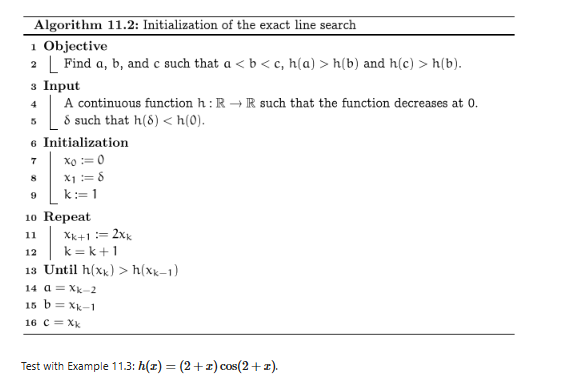

In [1]:
#biblioteca
using LinearAlgebra
using Plots

In [5]:
#Função 
h(x) = (2 + x) * cos(2 + x)

#Parametros iniciais
delta =  0.1

0.1

In [3]:
#Implementação no Algoritmo

function initialization_line_search(h, δ)
    # Inicialização
    x = Float64[0.0, δ]
    k = 2 
    
    println("Iniciando busca...")
    println("k=0: x=0.0, h(x)=$(h(0.0))")
    println("k=1: x=$δ, h(x)=$(h(δ))")

    # Loop de Repetição
    while true
        # x_{k+1} = 2 * x_k
        push!(x, 2 * x[k])
        k += 1
        
        val_atual = h(x[k])
        val_anterior = h(x[k-1])
        
        println("k=$(k-1): x=$(x[k]), h(x)=$val_atual")
        
        # Condição de parada: h(x_k) > h(x_{k-1})
        if val_atual > val_anterior
            break
        end
    end
    
    # Atribuição final (a, b, c)
    a = x[k-2]
    b = x[k-1]
    c = x[k]
    
    return a, b, c
end

initialization_line_search (generic function with 1 method)

In [6]:
# Executando 
a, b, c = initialization_line_search(h, delta)

println("\n--- Resultado Final ---")
println("Intervalo encontrado: a=$a, b=$b, c=$c")
println("Valores de h: h(a)=$(h(a)), h(b)=$(h(b)), h(c)=$(h(c))")

Iniciando busca...
k=0: x=0.0, h(x)=-0.8322936730942848
k=1: x=0.1, h(x)=-1.060176819659701
k=2: x=0.2, h(x)=-1.294702457961761
k=3: x=0.4, h(x)=-1.769744917298989
k=4: x=0.8, h(x)=-2.6382225538722426
k=5: x=1.6, h(x)=-3.228330298802929
k=6: x=3.2, h(x)=2.436286690761961

--- Resultado Final ---
Intervalo encontrado: a=0.8, b=1.6, c=3.2
Valores de h: h(a)=-2.6382225538722426, h(b)=-3.228330298802929, h(c)=2.436286690761961


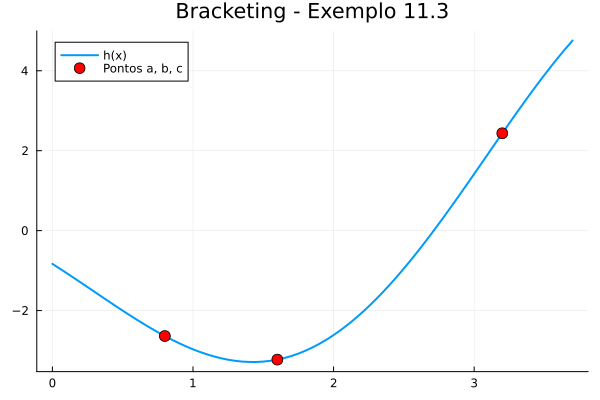

In [7]:
# Criando pontos para o gráfico
rango = 0:0.05:c+0.5
plot(rango, h.(rango), label="h(x)", lw=2, title="Bracketing - Exemplo 11.3")
scatter!([a, b, c], [h(a), h(b), h(c)], color=:red, label="Pontos a, b, c", markersize=6)

-----------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------

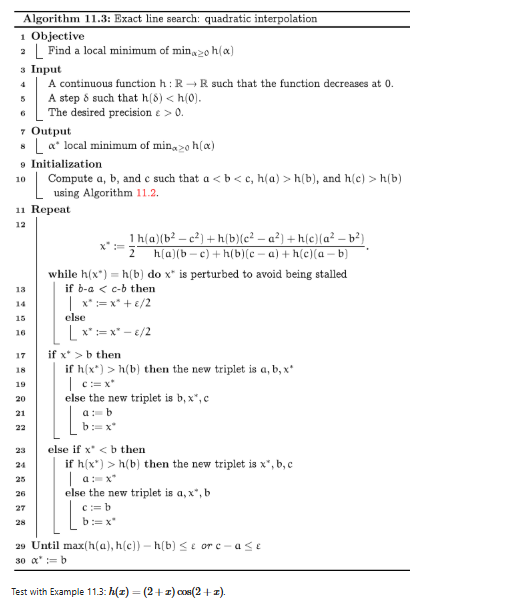

In [8]:
#Biblioteca

using LinearAlgebra
using Plots

In [10]:
#Função
h(x) = (2 + x) * cos(2 + x)

#Parâmetros
delta = 0.1
epsilon = 1e-5

1.0e-5

In [14]:
#Algoritmo

function algorithm_11_2(h, delta)
    x = [0.0, delta]
    k = 2
    while h(x[k]) <= h(x[k-1])
        push!(x, 2 * x[k])
        k += 1
    end
    return x[k-2], x[k-1], x[k]
end

# Obtendo os pontos iniciais para o SQI
a_init, b_init, c_init = algorithm_11_2(h, delta)
println("Trio inicial encontrado: a=$a_init, b=$b_init, c=$c_init")

Trio inicial encontrado: a=0.8, b=1.6, c=3.2


In [16]:
#Implementação do Algoritmo

function algorithm_11_3(h, a, b, c, eps)
    # Contador de iterações para evitar loops infinitos
    iter = 0
    
    while (c - a) > eps
        iter += 1
        
        # Valores da função nos pontos atuais
        ha, hb, hc = h(a), h(b), h(c)
        
        # Fórmula do vértice da parábola (x'')
        # Derivada da interpolação de Lagrange
        num = ha * (b^2 - c^2) + hb * (c^2 - a^2) + hc * (a^2 - b^2)
        den = 2 * (ha * (b - c) + hb * (c - a) + hc * (a - b))
        
        # Se o denominador for zero, os pontos são colineares
        if den == 0
            break
        end
        
        x_double_prime = num / den
        
        # Perturbação se x'' coincidir com b 
        if x_double_prime == b
            x_double_prime = b + eps/10
        end
        
        hx_new = h(x_double_prime)
        
        # Lógica de atualização do trio 
        if x_double_prime > b
            if hx_new > hb
                c = x_double_prime
            else
                a = b
                b = x_double_prime
            end
        else # x_double_prime < b
            if hx_new > hb
                a = x_double_prime
            else
                c = b
                b = x_double_prime
            end
        end
        
        if iter > 100 # Segurança
            break
        end
    end
    
    return b # b sempre será o ponto central, o melhor estimador do mínimo
end


algorithm_11_3 (generic function with 1 method)

In [17]:
#Executando
x_min = algorithm_11_3(h, a_init, b_init, c_init, epsilon)
println("O mínimo local aproximado é x* = $x_min")
println("Valor da função no mínimo: h(x*) = $(h(x_min))")

O mínimo local aproximado é x* = 1.4256184490394652
Valor da função no mínimo: h(x*) = -3.2883713955908966


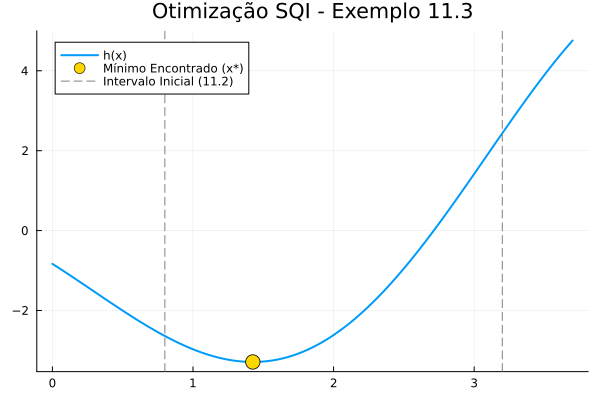

In [18]:
#Grafico
x_axis = 0:0.01:(c_init + 0.5)
plot(x_axis, h.(x_axis), label="h(x)", lw=2, title="Otimização SQI - Exemplo 11.3")
scatter!([x_min], [h(x_min)], color=:gold, markersize=8, label="Mínimo Encontrado (x*)")
vline!([a_init, c_init], line=:dash, color=:gray, label="Intervalo Inicial (11.2)")

///////////////////////////////////////////////////////////////////////////////////////////////////////////
///////////////////////////////////////////////////////////////////////////////////////////////////////////

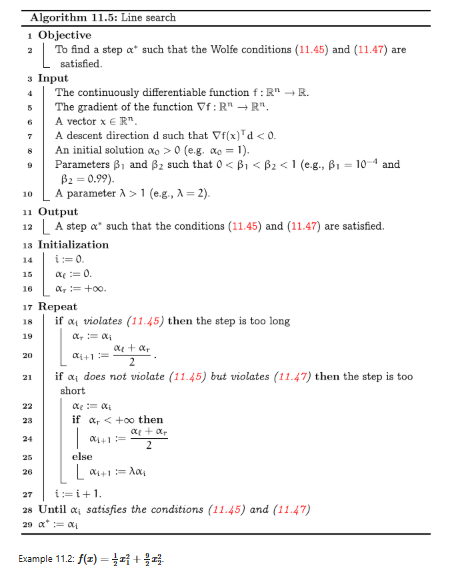

In [19]:
#Biblioteca
using LinearAlgebra
using Plots

#Função
f(x) = 0.5 * x[1]^2 + 4.5 * x[2]^2

# Gradiente da função

∇f(x) = [x[1], 9.0 * x[2]]

# Parâmetros Iniciais

x = [10.0, 1.0]           # Ponto inicial
d = -∇f(x)                # Direção de descida (máxima descida)
α_0 = 1.0                 # Passo inicial
β1 = 1e-4                 # Parâmetro de Armijo
β2 = 0.9                  # Parâmetro de Curvatura
λ = 2.0                   # Fator de expansão


2.0

In [21]:
#Algoritmo de Busca Linear

function line_search_wolfe(f, ∇f, x, d, α0, β1, β2, λ)
    i = 0
    α_i = α0
    α_l = 0.0
    α_r = Inf
    
    history = [α_i] # Para visualização posterior

    while true
        ϕ_0 = f(x)
        grad_0 = ∇f(x)
        ϕ_αi = f(x + α_i * d)
        grad_αi = ∇f(x + α_i * d)

        # Condição 11.45 (Armijo/Sufficient Decrease)
        violate_11_45 = ϕ_αi > ϕ_0 + β1 * α_i * (grad_0' * d)
        
        # Condição 11.47 (Curvature)
        violate_11_47 = (grad_αi' * d) < β2 * (grad_0' * d)

        if violate_11_45
            # Passo muito longo
            α_r = α_i
            α_i = (α_l + α_r) / 2
        elseif violate_11_47
            # Passo muito curto
            α_l = α_i
            if α_r < Inf
                α_i = (α_l + α_r) / 2
            else
                α_i = λ * α_i
            end
        else
            # Ambas as condições satisfeitas
            return α_i, history
        end
        
        push!(history, α_i)
        i += 1
        if i > 100 break end 
    end
end

line_search_wolfe (generic function with 1 method)

In [22]:
#Execução
α_star, α_history = line_search_wolfe(f, ∇f, x, d, α_0, β1, β2, λ)

(0.25, [1.0, 0.5, 0.25])

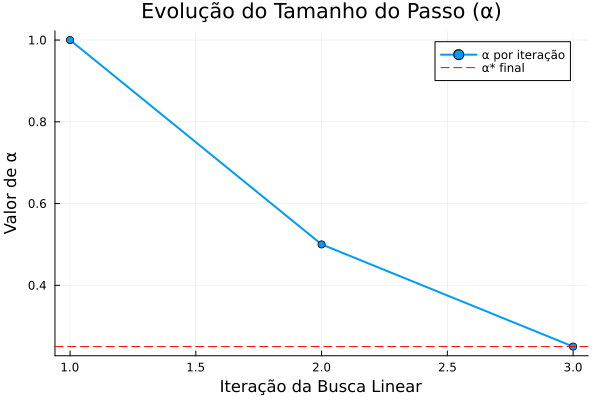

In [23]:
# Plotagem da evolução do passo

plot(α_history, marker=:circle, 
     title="Evolução do Tamanho do Passo (α)",
     xlabel="Iteração da Busca Linear", 
     ylabel="Valor de α",
     label="α por iteração",
     lw=2)
hline!([α_star], label="α* final", linestyle=:dash, color=:red)

////////////////////////////////////////////////////////////////////////////////////////////////////////////////////
////////////////////////////////////////////////////////////////////////////////////////////////////////////////////

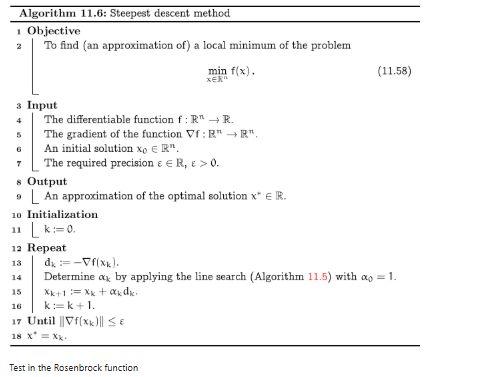

In [24]:
#Biblioteca 
using LinearAlgebra
using Plots


In [25]:
#Função : de Rosenbrock definida

# f(x) = (1 - x₁)² + 100(x₂ - x₁²)²
f(x) = (1.0 - x[1])^2 + 100.0 * (x[2] - x[1]^2)^2

# Gradiente analítico de f(x)
function grad_f(x)
    g1 = -2.0 * (1.0 - x[1]) - 400.0 * x[1] * (x[2] - x[1]^2)
    g2 = 200.0 * (x[2] - x[1]^2)
    return [g1, g2]
end

grad_f (generic function with 1 method)

In [26]:
#Algoritmo de Steepest Descent

function steepest_descent(x0, eps=1e-5, alpha=0.001, max_iter=10000)
    x_k = x0
    history = [x0] # Para plotar o caminho depois
    
    for k in 1:max_iter
        dk = -grad_f(x_k)
        
        # Critério de parada: norma do gradiente
        if norm(dk) <= eps
            println("Convergência atingida na iteração $k")
            break
        end
        
        # Atualização (Passo 15 do algoritmo)
        x_k = x_k + alpha * dk
        push!(history, x_k)
    end
    
    return x_k, history
end

steepest_descent (generic function with 4 methods)

In [27]:
# Configurações iniciais

x_start = [-1.2, 1.0]

#Solução
solucao, caminho = steepest_descent(x_start)

([0.992355840411716, 0.9847393841944715], [[-1.2, 1.0], [-0.9843999999999999, 1.088], [-1.0272715665664, 1.0642086720000001], [-1.0268830682337082, 1.0624243118951573], [-1.0260888245031374, 1.0608372166811408], [-1.0253114876941536, 1.0592414284989586], [-1.0245327492086536, 1.0576458721586866], [-1.0237533848853388, 1.0560501685671575], [-1.0229733612874716, 1.0544543334665637], [-1.0221926782481663, 1.0528583663540085]  …  [0.9923279701855849, 0.984683958051702], [0.9923310719502424, 0.9846901265238902], [0.9923341724454428, 0.9846962924906956], [0.992337271671718, 0.9847024559531528], [0.9923403696296004, 0.984708616912296], [0.9923434663196213, 0.9847147753691592], [0.9923465617423122, 0.9847209313247757], [0.9923496558982043, 0.9847270847801782], [0.9923527487878286, 0.9847332357363995], [0.992355840411716, 0.9847393841944715]])

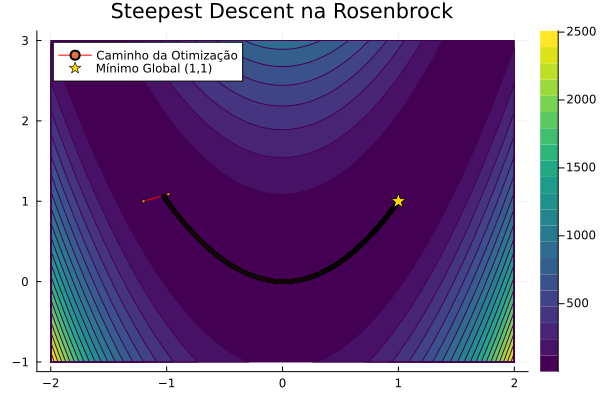

In [28]:
#Grafico
# Criando o gráfico de contorno
x_range = range(-2, 2, length=100)
y_range = range(-1, 3, length=100)
p = contour(x_range, y_range, (x,y) -> f([x,y]), levels=20, fill=true, c=:viridis, title="Steepest Descent na Rosenbrock")

# Extraindo coordenadas do histórico para plotar a trajetória
path_x = [p[1] for p in caminho]
path_y = [p[2] for p in caminho]

plot!(p, path_x, path_y, marker=:circle, markersize=2, linecolor=:red, label="Caminho da Otimização")
scatter!(p, [1.0], [1.0], color=:gold, markershape=:star, markersize=8, label="Mínimo Global (1,1)")